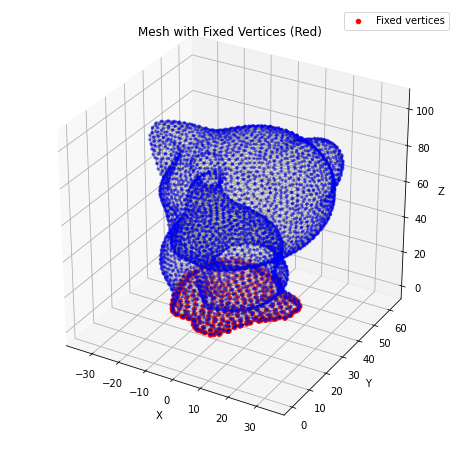

Using mesh with 4103 vertices and 8206 faces


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import trimesh
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# -------------------------------
# 1. Load OBJ mesh
# -------------------------------
from pathlib import Path
mesh_path = Path("Models") / "kitten_OBJ.obj" # Replace with your mesh path
mesh = trimesh.load(mesh_path, process=True) # if needed, disable Trimesh’s automatic vertex merging (process=False)

V = torch.tensor(mesh.vertices, dtype=torch.float32)
F = torch.tensor(mesh.faces, dtype=torch.long)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
V = V.to(device)
F = F.to(device)

 
# -------------------------------
# Normalize vertex coordinates
# -------------------------------
# Shift so that min(Z) = 0
z_min = V[:, 2].min()
V[:, 2] = V[:, 2] - z_min

y_min = V[:, 1].min()
V[:, 1] = V[:, 1] - y_min


# -------------------------------
# Fix vertices based on Z height
# -------------------------------
z_vals = V[:, 2]
z_min = V[:, 2].min()
z_max = z_min + 2.0  # still one unit thickness
fixed_mask = ((z_vals >= z_min) & (z_vals <= z_max) )
 
#y_vals = V[:,1]
#y_max = V[:, 1].max()
#y_min = y_max - 10.0
#fixed_mask = ((z_vals >= z_min) & (z_vals <= z_max)&  (y_vals >= y_min) & (z_vals <= y_max))

 
# 2b. Visualize mesh and fixed vertices
 
V_np = V.detach().cpu().numpy()
F_np = F.detach().cpu().numpy()
fixed_mask_np = fixed_mask.detach().cpu().numpy()

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")
mesh_collection = Poly3DCollection(V_np[F_np], alpha=0.1, facecolor="gray", edgecolor="k")
ax.add_collection3d(mesh_collection)
ax.scatter(V_np[:,0], V_np[:,1], V_np[:,2], s=5, c="blue", alpha=0.4)
ax.scatter(V_np[fixed_mask_np,0], V_np[fixed_mask_np,1], V_np[fixed_mask_np,2],
           s=20, c="red", label="Fixed vertices")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title("Mesh with Fixed Vertices (Red)"); ax.legend()
plt.show()
print(f"Using mesh with {len(V)} vertices and {len(F)} faces")

#mesh.export("Gyroid_original.obj")
#np.savetxt("Vertex_locations_armadCOARSE.txt", V_np)

In [2]:

# -------------------------------
# 3. Vertex displacement network
# -------------------------------
class VertexDisplacementNN(nn.Module):
    def __init__(self, in_dim=3, hidden=128, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(depth-1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers.append(nn.Linear(hidden, 3))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

#net = VertexDisplacementNN().to(device) # 3 hidden layers 128 neurons

net = VertexDisplacementNN(in_dim=3, hidden=192, depth=5).to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-4)  # learning rate - CHANGE HERE **1e-3 or 1e-4

# -------------------------------
# 4. Height-weighted overhang loss
# -------------------------------
 
def overhang_loss_vertex_weighted_stable(V, F, alpha_max=135.0):
    k = torch.tensor([0., 0., 1.], dtype=V.dtype, device=V.device)
    v0, v1, v2 = V[F[:,0]], V[F[:,1]], V[F[:,2]]
    fn = torch.cross(v1 - v0, v2 - v0)
    fn_norm = fn.norm(dim=1, keepdim=True).clamp(min=1e-12)
    n_unit = fn / fn_norm

    cos_thresh = math.cos(alpha_max * math.pi / 180.0)
    violation = torch.relu(cos_thresh - (n_unit * k).sum(dim=1))

    # --- Fixed part: shift z so all heights ≥ 0 ---
    face_heights = (v0[:,2] + v1[:,2] + v2[:,2]) / 3.0
    face_heights = face_heights - face_heights.min()    # ensure min = 0
    face_heights = torch.relu(face_heights)

    H_max = face_heights.max().clamp(min=1e-9)
    weights = face_heights / H_max

    vertex_violation = torch.zeros(V.shape[0], device=V.device, dtype=V.dtype)
    for i in range(3):
        vertex_violation.index_add_(0, F[:, i], violation * weights / 3.0)

    return vertex_violation.mean().abs()



# -------------------------------
# 5. Cotangent Laplacian smoothness (vectorized)
# -------------------------------
def cotangent_laplacian_loss(V, F):
    v0 = V[F[:,0]]; v1 = V[F[:,1]]; v2 = V[F[:,2]]
    e0 = v2 - v1; e1 = v0 - v2; e2 = v1 - v0
    face_normals = torch.cross(v1 - v0, v2 - v0)
    face_areas = 0.5 * face_normals.norm(dim=1) + 1e-9
    cot0 = (e1 * -e2).sum(dim=1) / (torch.norm(torch.cross(e1, -e2), dim=1) + 1e-9)
    cot1 = (e2 * -e0).sum(dim=1) / (torch.norm(torch.cross(e2, -e0), dim=1) + 1e-9)
    cot2 = (e0 * -e1).sum(dim=1) / (torch.norm(torch.cross(e0, -e1), dim=1) + 1e-9)
    L = torch.zeros_like(V)
    idx0, idx1, idx2 = F[:,0], F[:,1], F[:,2]
    L.index_add_(0, idx0, cot1[:,None]*(v1-v0) + cot2[:,None]*(v2-v0))
    L.index_add_(0, idx1, cot2[:,None]*(v2-v1) + cot0[:,None]*(v0-v1))
    L.index_add_(0, idx2, cot0[:,None]*(v0-v2) + cot1[:,None]*(v1-v2))
    w_sum = torch.zeros(V.shape[0], device=V.device)
    w_sum.index_add_(0, idx0, cot1 + cot2)
    w_sum.index_add_(0, idx1, cot2 + cot0)
    w_sum.index_add_(0, idx2, cot0 + cot1)
    w_sum = w_sum[:,None] + 1e-9
    L = L / w_sum
    return (L**2).sum(dim=1).mean()

# -------------------------------
# 6. Geometric deviation
# -------------------------------
def geometric_deviation(V_new, V_orig):
    return ((V_new - V_orig)**2).sum(dim=-1).mean()





In [3]:
# -------------------------------
# 7. Training loop with early stopping
# -------------------------------
import time
start_time = time.time()   #  start time 


num_iters = 500

# lambda_over = 10 if run with displacement smoothing, 5 for laplacian smoothing + deviation
lambda_over = 10
lambda_lap = 0.1
lambda_dev = 0.05

lambda_sup = 0.05

max_dev_threshold = 0.2

# early stopping params
patience_k = 49        # check stagnation over k iterations
tolerance = 1e-5       # threshold for change in loss
loss_history = []

# record losses
loss_logs = {
    "total": [],
    "overhang": [],
    "laplacian": [] 
     
}


for it in range(num_iters):
    optimizer.zero_grad()
    delta_V = net(V)
    delta_V[fixed_mask] = 0.0  # enforce fixed vertices
    V_new = V + delta_V

    L_over = overhang_loss_vertex_weighted_stable(V_new, F)
    L_lap  = cotangent_laplacian_loss(V_new, F)
    L_dev  = geometric_deviation(V_new, V)
    

    # soft deviation penalty
    dev_penalty = lambda_dev * (1.0 + torch.relu(L_dev - max_dev_threshold) * 5.0)
    
    
    loss = lambda_over * L_over + lambda_lap * L_lap + dev_penalty * L_dev  
    #loss = lambda_sup * L_supvol + lambda_lap * L_lap + dev_penalty * L_dev 
 
    loss.backward()
    optimizer.step()

    # log history
    loss_history.append(loss.item())
    
    # ---- log individual losses ----
    loss_logs["total"].append(loss.item())
    loss_logs["overhang"].append(L_over.item())
    loss_logs["laplacian"].append(L_lap.item()) 
      
     
    if it % 50 == 0:
        print(f"Iter {it}: Total={loss.item():.6f}, Overhang={L_over.item():.6f}, "
              f"Lap={L_lap.item():.6f}, Dev={L_dev.item():.6f}, λ_dev={dev_penalty.item():.4f}")
    

    # ---- Termination criterion 1: MSPVD too high (after k iters) ----
    if it > 500 and L_dev.item() > max_dev_threshold:
        print(f"Stopped early at iter {it} due to exceeding deviation threshold ({L_dev.item():.6f})")
        break


    # ---- Termination criterion 2: loss stagnation ----
    if it > patience_k:
        recent_change = abs(loss_history[-1] - loss_history[-patience_k])
        if recent_change < tolerance:
            print(f"Stopped early at iter {it} due to stagnating loss (Δ={recent_change:.6e})")
            break

end_time = time.time()   # <-- end timer
total_time = end_time - start_time
avg_time = total_time / num_iters

 # 8. Save optimized mesh
# -------------------------------
V_optimized = V_new.detach().cpu().numpy()
mesh.vertices = V_optimized

mesh.export("optimized_kitten.obj")
print("Optimized mesh saved to kitten_optimized.obj")
print(f"Using mesh with {len(V_optimized)} vertices")


print("\n============================")
print(f"Total optimization time: {total_time:.2f} seconds")
print(f"Average time per iteration: {avg_time:.4f} seconds")

 

Iter 0: Total=0.109012, Overhang=0.005519, Lap=0.117574, Dev=0.410183, λ_dev=0.1025
Iter 50: Total=0.064163, Overhang=0.005139, Lap=0.117531, Dev=0.020445, λ_dev=0.0500
Iter 100: Total=0.061781, Overhang=0.004780, Lap=0.117131, Dev=0.045325, λ_dev=0.0500
Iter 150: Total=0.058420, Overhang=0.004299, Lap=0.117026, Dev=0.074549, λ_dev=0.0500
Iter 200: Total=0.054374, Overhang=0.003681, Lap=0.117395, Dev=0.116496, λ_dev=0.0500
Iter 250: Total=0.050395, Overhang=0.003144, Lap=0.117863, Dev=0.143377, λ_dev=0.0500
Iter 300: Total=0.045266, Overhang=0.002495, Lap=0.118761, Dev=0.168824, λ_dev=0.0500
Iter 350: Total=0.041312, Overhang=0.002227, Lap=0.120140, Dev=0.140617, λ_dev=0.0500
Iter 400: Total=0.042111, Overhang=0.002118, Lap=0.119907, Dev=0.178811, λ_dev=0.0500
Iter 450: Total=0.038334, Overhang=0.001668, Lap=0.120114, Dev=0.192817, λ_dev=0.0500
Optimized mesh saved to kitten_optimized.obj
Using mesh with 4103 vertices

Total optimization time: 38.32 seconds
Average time per iteration: 

In [4]:
import trimesh
import torch
 
# After training: save NN and optimized mesh
 
torch.save(net.state_dict(), "trained_nn.pth")

# -------------------------------
# 2. Reload NN for later use
# note - the no of hidden layers and neurons should be same as the network we used to run the initial optimisation
net = VertexDisplacementNN(in_dim=3, hidden=192, depth=5).to(device)
net.load_state_dict(torch.load("trained_nn.pth", map_location=device))
net.eval()


VertexDisplacementNN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=192, bias=True)
    (1): ReLU()
    (2): Linear(in_features=192, out_features=192, bias=True)
    (3): ReLU()
    (4): Linear(in_features=192, out_features=192, bias=True)
    (5): ReLU()
    (6): Linear(in_features=192, out_features=192, bias=True)
    (7): ReLU()
    (8): Linear(in_features=192, out_features=192, bias=True)
    (9): ReLU()
    (10): Linear(in_features=192, out_features=3, bias=True)
  )
)

In [8]:
# -------------------------------
# Fine-Tuning Neural Deformation Field on Subdivided Mesh
# -------------------------------

 
# ---- Fine-tuning (corrected) ----
import torch
import torch.optim as optim
import time
import numpy as np
import trimesh
import pyvista as pv

# assume: net is loaded (coarse-trained), device set, and overhang/cotan functions defined

# 1) Load original and subdivide (PyVista)
mesh_tr = trimesh.load("Models/kitten_OBJ.obj", process=True)
mesh_pv = pv.PolyData(mesh_tr.vertices, np.hstack((np.full((len(mesh_tr.faces),1),3), mesh_tr.faces)).astype(np.int32))

# Subdivision level (1,2 or 3)
mesh_subdiv_pv = mesh_pv.subdivide(1, subfilter='loop')   # choose level
print("Subdiv vertices:", len(mesh_subdiv_pv.points))

# Convert PyVista mesh → Trimesh
faces_int = mesh_subdiv_pv.faces.reshape(-1, 4)[:, 1:]
mesh_trimesh = trimesh.Trimesh(vertices=mesh_subdiv_pv.points, faces=faces_int)
 

# 2) Build torch arrays and keep original copy
V_sub_orig = torch.tensor(mesh_subdiv_pv.points, dtype=torch.float32, device=device).clone()
V_sub = V_sub_orig.clone()   # will be used as inputs; don't in-place modify V_sub_orig
faces_arr = mesh_subdiv_pv.faces.reshape(-1,4)[:,1:].astype(np.int64)
F_sub = torch.tensor(faces_arr, dtype=torch.long, device=device)

# OPTIONAL: If you want to freeze coarse vertices (only fine vertices optimized),
 
freeze_coarse_vertices = False   # <-- set True to freeze coarse vertices
freeze_mask = None
if freeze_coarse_vertices:
    from scipy.spatial import cKDTree
    coarse_coords = np.asarray(mesh_tr.vertices)        # original coarse positions
    subdiv_coords = np.asarray(mesh_subdiv_pv.points)   # subdivided positions
    kdt = cKDTree(subdiv_coords)
    # For each coarse vertex, find nearest subdiv index
    _, idxs = kdt.query(coarse_coords, k=1)
    freeze_mask_np = np.zeros(len(subdiv_coords), dtype=bool)
    freeze_mask_np[idxs] = True
    freeze_mask = torch.tensor(freeze_mask_np, dtype=torch.bool, device=device)
    print(f"Freezing {freeze_mask.sum().item()} subdiv vertices corresponding to coarse vertices.")

# 3) Fine-tuning setup
net.train()
ft_optimizer = optim.Adam(net.parameters(), lr=1e-4)
max_iters = 400


# loss weights (tune)
lambda_over_ft = 10.0
lambda_lap_ft  = 0.1
lambda_dev_ft  = 0.05     # base deviation weight (we will use soft multiplier)
max_dev_threshold = 0.1   # same as coarse
 
 

print("Starting fine-tuning...")
t0 = time.time()

for it in range(max_iters):
    ft_optimizer.zero_grad()
    
    #the neural deformation field evaluated at the subdivided vertices
    delta = net(V_sub)  # (M,3)
    
    # updated vertices
    V_new = V_sub + delta

    # compute losses
    L_over = overhang_loss_vertex_weighted_stable(V_new, F_sub)
    L_lap  = cotangent_laplacian_loss(V_new, F_sub)
    #L_lap  = cotangent_laplacian_loss(delta, F_sub) # this smooth outs the displacement field
    L_dev_raw = (delta**2).sum(dim=1).mean()

    # soft deviation penalty
    dev_scale = 1.0 + torch.relu(L_dev_raw - max_dev_threshold) * 5.0
    L_dev = L_dev_raw * lambda_dev_ft * dev_scale

    loss = lambda_over_ft * L_over + lambda_lap_ft * L_lap + L_dev

    loss.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
    ft_optimizer.step()

    if it % 50 == 0 or it == max_iters-1:
        print(f"[FT {it}] loss={loss.item():.6f} over={L_over.item():.6f} lap={L_lap.item():.6f} dev={L_dev_raw.item():.6f}")
    
    if it > 300 and L_dev_raw.item() > max_dev_threshold:
        print(f"Stopped early at iter {it} due to exceeding deviation threshold ({L_dev_raw.item():.6f})")
        break
        
print("Fine-tuning done. Time:", time.time()-t0)

# 4) Save/apply final deformation and export
net.eval()
with torch.no_grad():
    delta_final = net(V_sub)
    if freeze_coarse_vertices:
        delta_final[freeze_mask] = 0.0
    V_sub_final = (V_sub + delta_final).cpu().numpy()

mesh_subdiv_pv.points = V_sub_final
faces_np = faces_arr
mesh_out = trimesh.Trimesh(vertices=mesh_subdiv_pv.points, faces=faces_np)
mesh_out.export("optimized_finetuned_kitten.obj")
print("Exported optimized fine mesh")
 

Subdiv vertices: 16412
Starting fine-tuning...
[FT 0] loss=0.005277 over=0.000236 lap=0.006973 dev=0.044409
[FT 50] loss=0.002209 over=0.000134 lap=0.006963 dev=0.003522
[FT 100] loss=0.001970 over=0.000110 lap=0.006960 dev=0.003374
[FT 150] loss=0.001742 over=0.000088 lap=0.006949 dev=0.003441
[FT 200] loss=0.001559 over=0.000071 lap=0.006946 dev=0.003011
[FT 250] loss=0.001469 over=0.000065 lap=0.006942 dev=0.002516
[FT 300] loss=0.001416 over=0.000061 lap=0.006936 dev=0.002264
[FT 350] loss=0.001362 over=0.000057 lap=0.006931 dev=0.001972
[FT 399] loss=0.001330 over=0.000055 lap=0.006930 dev=0.001784
Fine-tuning done. Time: 89.67348313331604
Exported optimized fine mesh
